# Tutorial 6

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn as sk

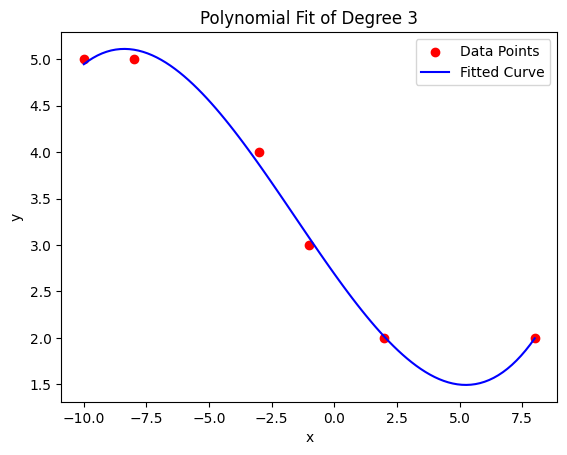

Predicted value at x=9: 2.4660977113619698


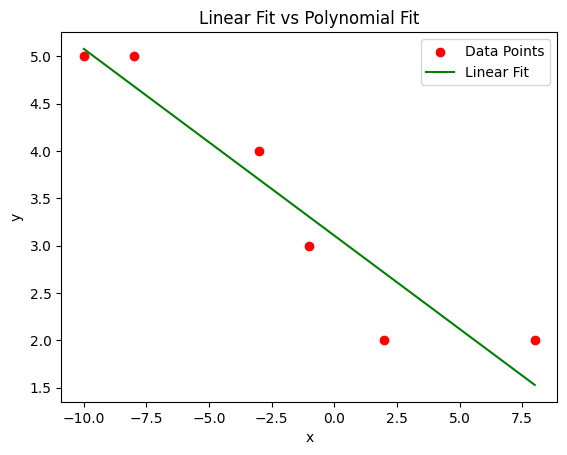

In [6]:
# Question 2:

x = np.array([[-10],[-8],[-3],[-1],[2],[8]])
y = np.array([[5],[5],[4],[3],[2],[2]])

poly = sk.preprocessing.PolynomialFeatures(3)
P = poly.fit_transform(x)

w = np.linalg.inv(P.T @ P) @ P.T @ y

#Sketch the data points and the fitted curve
x_fit = np.linspace(-10, 8, 100).reshape(-1,1)
P_fit = poly.transform(x_fit)
y_fit = P_fit @ w
plt.scatter(x, y, color='red', label='Data Points')
plt.plot(x_fit, y_fit, color='blue', label='Fitted Curve')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Polynomial Fit of Degree 3')
plt.legend()
plt.show()

# Test point x=9:
x_test = np.array([[9]])
P_test = poly.transform(x_test)
y_test = P_test @ w
print(f"Predicted value at x=9: {y_test[0][0]}")


#Compare with linear regression:
x_weighted = np.column_stack((np.ones(x.shape[0]), x))
w_linear = np.linalg.inv(x_weighted.T @ x_weighted) @ x_weighted.T @ y
y_linear_fit = x_weighted @ w_linear
plt.scatter(x, y, color='red', label='Data Points')
plt.plot(x, y_linear_fit, color='green', label='Linear Fit')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Linear Fit vs Polynomial Fit')
plt.legend()
plt.show() 

In [11]:
# Question 3: 

X = np.array([[1,0,1],[1,-1,1]])
poly = sk.preprocessing.PolynomialFeatures(3)
P = poly.fit_transform(X)
print(P)

y = np.array([[0],[1]])

lamb = 1.0

# Unique solution using dual form:
w = P.T @ np.linalg.inv(P@P.T + lamb * np.eye(P.shape[0])) @ y
print("Weights from dual form:", w)

# Unique solution using primal form:
w_primal = np.linalg.inv(P.T @ P + lamb * np.eye(P.shape[1])) @ P.T @ y
print("Weights from primal form:", w_primal)


[[ 1.  1.  0.  1.  1.  0.  1.  0.  0.  1.  1.  0.  1.  0.  0.  1.  0.  0.
   0.  1.]
 [ 1.  1. -1.  1.  1. -1.  1.  1. -1.  1.  1. -1.  1.  1. -1.  1. -1.  1.
  -1.  1.]]
Weights from dual form: [[ 0.00763359]
 [ 0.00763359]
 [-0.08396947]
 [ 0.00763359]
 [ 0.00763359]
 [-0.08396947]
 [ 0.00763359]
 [ 0.08396947]
 [-0.08396947]
 [ 0.00763359]
 [ 0.00763359]
 [-0.08396947]
 [ 0.00763359]
 [ 0.08396947]
 [-0.08396947]
 [ 0.00763359]
 [-0.08396947]
 [ 0.08396947]
 [-0.08396947]
 [ 0.00763359]]
Weights from primal form: [[ 0.00763359]
 [ 0.00763359]
 [-0.08396947]
 [ 0.00763359]
 [ 0.00763359]
 [-0.08396947]
 [ 0.00763359]
 [ 0.08396947]
 [-0.08396947]
 [ 0.00763359]
 [ 0.00763359]
 [-0.08396947]
 [ 0.00763359]
 [ 0.08396947]
 [-0.08396947]
 [ 0.00763359]
 [-0.08396947]
 [ 0.08396947]
 [-0.08396947]
 [ 0.00763359]]


In [23]:
# Question 4:

X = np.array([[0],[0],[0.5],[0.3],[0.8]])
X = np.column_stack((np.ones(X.shape[0]), X))
y = np.array([[1],[1],[2],[1],[2]])

onehot_encoder = sk.preprocessing.OneHotEncoder(sparse_output=False)
Y_onehot = onehot_encoder.fit_transform(y)

w = np.linalg.inv(X.T @ X) @ X.T @ Y_onehot
print("Weights for one-hot encoded regression:", w)


#testing:

X_test = np.array([[1,-0.1],[1,0.4]])
y_test = X_test @ w
print("Predicted probabilities for test points:", y_test)
# y_testing_class = np.argmax(y_test, axis=1)

# OR: 
y_testing_class = [[1 if y==max(x) else 0 for y in x] for x in y_test]
print("Predicted classes for test points:", y_testing_class)

Weights for one-hot encoded regression: [[ 1.05128205 -0.05128205]
 [-1.41025641  1.41025641]]
Predicted probabilities for test points: [[ 1.19230769 -0.19230769]
 [ 0.48717949  0.51282051]]
Predicted classes for test points: [[1, 0], [0, 1]]


In [25]:
# Question 5:

X = np.array([[-1],[0],[0.5],[0.3],[0.8]])
y = np.array([[1],[1],[2],[3],[2]])

X = np.column_stack((np.ones(X.shape[0]), X))
onehot_encoder = sk.preprocessing.OneHotEncoder(sparse_output=False)
Y_onehot = onehot_encoder.fit_transform(y)

w = np.linalg.inv(X.T @ X) @ X.T @ Y_onehot
print("Weights for one-hot encoded regression:", w)

#testing:

X_test = np.array([[1,-0.1],[1,0.4]])
y_test = X_test @ w
# print("Predicted probabilities for test points:", y_test)
y_testing_class = [[1 if y==max(x) else 0 for y in x] for x in y_test]
print("Predicted classes for test points:", y_testing_class)


#Regression using 5th order polynomial model:
poly = sk.preprocessing.PolynomialFeatures(5)
X = np.array([[-1],[0],[0.5],[0.3],[0.8]])
P = poly.fit_transform(X) # use fit transform when first creating the polynomial features using training data
w_poly = P.T @ np.linalg.inv(P@P.T) @ Y_onehot
X_test_poly = np.array([[-0.1],[0.4]])
X_test_poly = poly.transform(X_test_poly) # only use transform, not fit_transform for testing data
y_test_poly = X_test_poly @ w_poly
y_testing_class_poly = [[1 if y==max(x) else 0 for y in x] for x in y_test_poly]
print("Predicted classes for test points using polynomial model:", y_testing_class_poly)

Weights for one-hot encoded regression: [[ 0.47798742  0.33333333  0.18867925]
 [-0.64989518  0.55555556  0.09433962]]
Predicted classes for test points: [[1, 0, 0], [0, 1, 0]]
Predicted classes for test points using polynomial model: [[1, 0, 0], [0, 0, 1]]


In [36]:
#Question 6:

iris = sk.datasets.load_iris()
X_train, X_test, y_train, y_test = sk.model_selection.train_test_split(iris.data, iris.target, test_size=0.26, random_state=42)

onehot_encoder = sk.preprocessing.OneHotEncoder(sparse_output=False)
Y_train_onehot = onehot_encoder.fit_transform(y_train.reshape(-1,1)) # reshape to make it a column vector for one-hot encoding
X_train_bias = np.column_stack((np.ones(X_train.shape[0]), X_train)) # add bias term
w = np.linalg.inv(X_train_bias.T @ X_train_bias) @ X_train_bias.T @ Y_train_onehot

X_test_bias = np.column_stack((np.ones(X_test.shape[0]), X_test)) # add bias term to test data
y_test_pred = X_test_bias @ w
y_test_pred_class = np.argmax(y_test_pred, axis=1)
accuracy = np.mean(y_test_pred_class == y_test)
print(f"Test set accuracy: {accuracy:.2f}")


poly = sk.preprocessing.PolynomialFeatures(2)

X_train_poly = poly.fit_transform(X_train)
w_poly = np.linalg.inv(X_train_poly.T @ X_train_poly) @ X_train_poly.T @ Y_train_onehot
X_test_poly = poly.transform(X_test)
y_test_poly_pred = X_test_poly @ w_poly
y_test_poly_pred_class = np.argmax(y_test_poly_pred, axis=1)
accuracy_poly = np.mean(y_test_poly_pred_class == y_test)
print(f"Test set accuracy with polynomial features: {accuracy_poly:.2f}")

Test set accuracy: 0.85
Test set accuracy with polynomial features: 1.00
